# Árboles de decisión: clasificación

Los **árboles de decisión** (*Decision Trees*, DT) son un método de aprendizaje supervisado no paramétrico que se utiliza para tareas de **clasificación** y **regresión**. El objetivo es construir un modelo que pueda predecir el valor de una variable objetivo aprendiendo reglas de decisión simples basadas en las características de los datos.

En **minería de datos** nos interesa la **capacidad explicativa** de los DT: el modelo resultante es fácil de visualizar e interpretar, lo que permite comprender cómo se toman las decisiones.

Si bien existen otros modelos más complejos y precisos, como los **bosques aleatorios** o las **redes neuronales profundas**, estos suelen ser difíciles de explicar. Por eso, ha surgido una rama dentro de la inteligencia artificial dedicada a mejorar la interpretación de estos modelos complejos, conocida como [**Inteligencia Artificial Explicable**](https://www.ibm.com/es-es/think/topics/explainable-ai) (Explainable Artificial Intelligence, XAI).

**Clasificación**

Para realizar una clasificación multiclase, utilizaremos la clase [`DecisionTreeClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) de la biblioteca **scikit-learn**, la cual implementa una versión optimizada del algoritmo **CART**, que por el momento no admite variables categóricas.

Exploraremos algunas de sus funcionalidades aplicándolas a la base de datos de *clases de vinos* que analizamos en la Unidad 2.


## Librerias

In [1]:
!pip install feature-engine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 378.6/378.6 kB 4.0 MB/s eta 0:00:00


In [17]:
# Análisis exploratorio
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Preparación de los datos
from feature_engine.outliers import Winsorizer # remoción de outliers
from sklearn.preprocessing import StandardScaler

# Arboles de desición
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, RandomizedSearchCV

# Métricas
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)

In [3]:
# Función para visualizar resultados
def tableResult(label, prediction):
    table = pd.DataFrame({'Actual':label, 'Predicted':prediction})
    print(table)

## Base de datos: clases de vinos

Estos datos son el resultado de un análisis químico de vinos cultivados en la misma región de Italia pero procedentes de tres cultivos diferentes. El
análisis determinó las cantidades de 13 componentes presentes en cada uno de
los tres tipos de vino.

Fuente de datos: Aeberhard,Stefan y Forina,M. (1991). Wine. UCI Machine
Learning Repository. https://doi.org/10.24432/C5PC7J.

Contiene las variables:

1. Alcohol
2. Ácido málico
3. Cenizas
4. Alcalinidad de las cenizas
5. Magnesio
6. Fenoles totales
7. Flavonoides
8. Fenoles no flavonoides
9. Proantocianinas
10. Intensidad del color
11. Matiz
12. DO280/DO315 de los vinos diluidos
13. Prolina


In [4]:
!gdown 10eFUjq8xuCzlQC9KbGowJ06hqNvt2_70

Downloading...
From: https://drive.google.com/uc?id=10eFUjq8xuCzlQC9KbGowJ06hqNvt2_70
To: /content/Wine.csv
100% 11.5k/11.5k [00:00<00:00, 22.7MB/s]


In [5]:
df = pd.read_csv("Wine.csv")

### Estructura
Nombre de variables, variable objetivo, tipos de datos y faltantes.

In [6]:
# Variables
df.head()

,class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [7]:
# Tipo de datos y cantidad por variable
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   class                         178 non-null    int64  
 1   Alcohol                       178 non-null    float64
 2   Malic acid                    178 non-null    float64
 3   Ash                           178 non-null    float64
 4   Alcalinity of ash             178 non-null    float64
 5   Magnesium                     178 non-null    int64  
 6   Total phenols                 178 non-null    float64
 7   Flavanoids                    178 non-null    float64
 8   Nonflavanoid phenols          178 non-null    float64
 9   Proanthocyanins               178 non-null    float64
 10  Color intensity               178 non-null    float64
 11  Hue                           178 non-null    float64
 12  OD280/OD315 of diluted wines  178 non-null    float64
 13  Proli

In [8]:
# Establezco la variable objetivo como categórica
df['class'] = df['class'].astype('category')
df["class"].value_counts()

,count
class,
2,71
1,59
3,48


In [9]:
df.describe() # solo numérico y no null

,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


### Tipos de distribución
Gausiana, uniforme, logaritmica, etc.

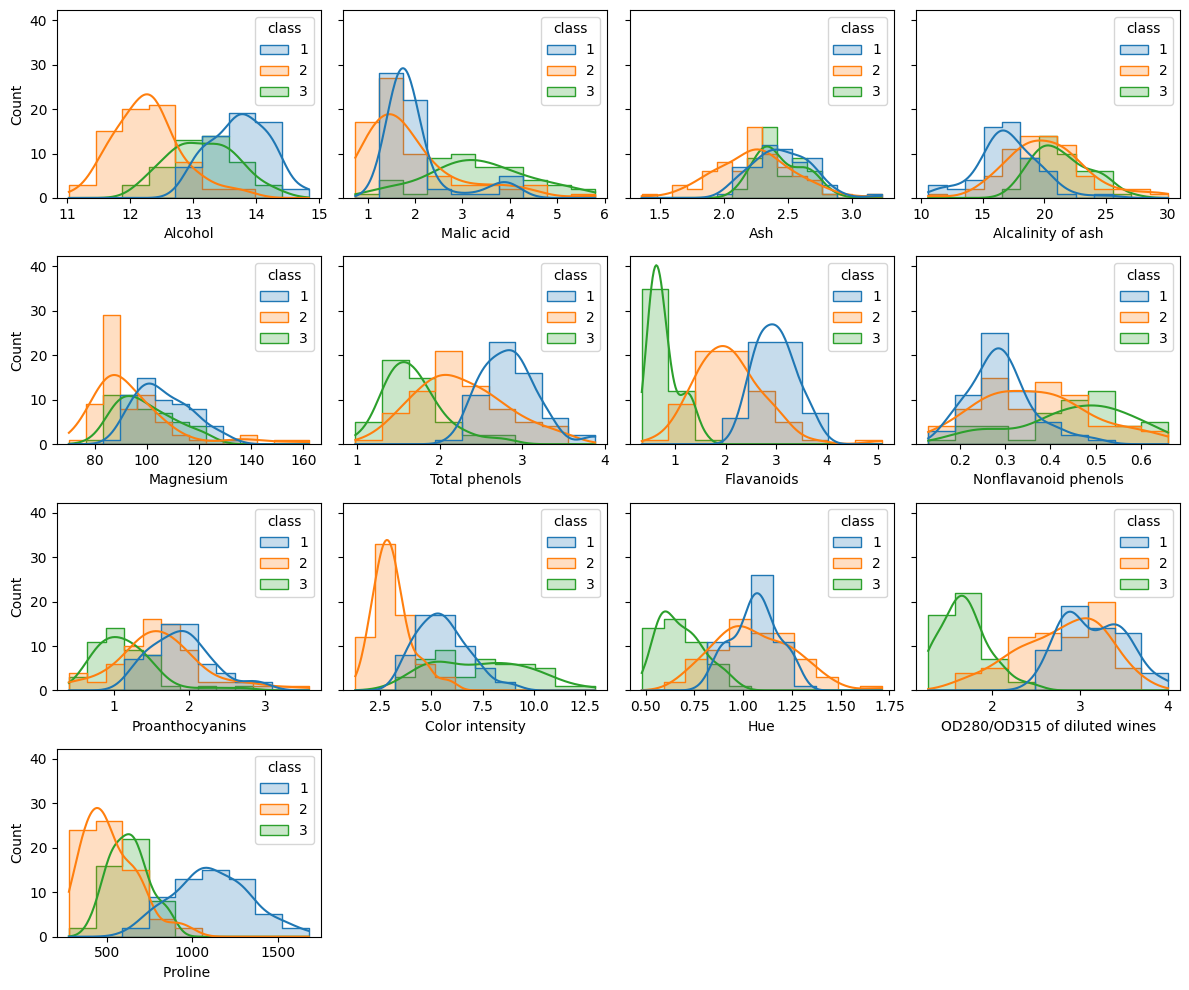

In [10]:
cols = df.select_dtypes(include=np.number).columns
fig, axes = plt.subplots(nrows=4, ncols=4, sharey=True,
                         figsize=(12, 10))
for i, col in enumerate(cols, 1):
    sns.histplot(data=df, x=col, hue='class', kde=True, element='step',
                 ax=axes.flatten()[i-1])

for i in range(len(cols)+1, 17):
    axes.flatten()[i-1].axis('off')

plt.tight_layout()
plt.show()

## División train-test

In [11]:
# Separo variable objetivo de datos
X = df.iloc[:, 1:]
y = df.iloc[:, 0]

In [12]:
# Obtengo datos de entrenamiento y de testeo
Xtrn, Xtst, ytrn, ytst  = train_test_split(X, y, test_size=0.2,
                            random_state=13, shuffle=True, stratify=y)

## Análisis exploratorio

### Correlación entre variables
El método de correlación de `'pearson'` mide la relación lineal entre dos variables continuas, para variables ordinales se usa el método de `'spearman'`.

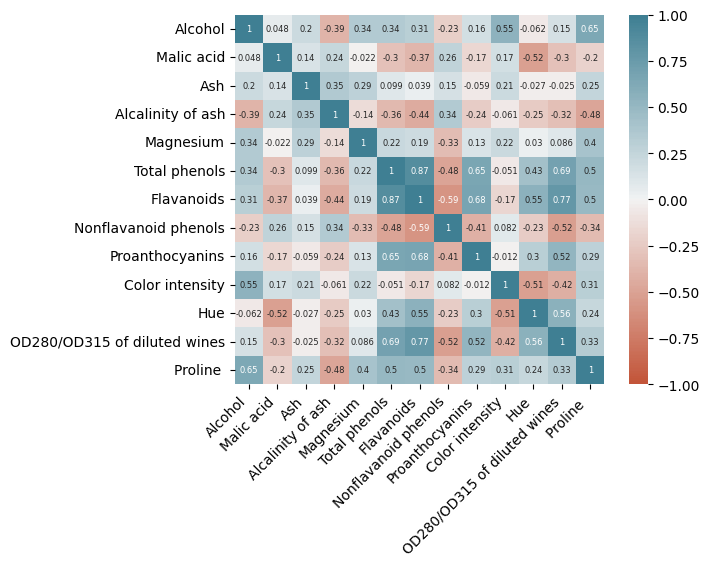

In [13]:
corr = Xtrn.corr(method='pearson')
ax = sns.heatmap(
    corr,
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True,
    annot = True,
    annot_kws = {'size': 6}
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment='right'
)
plt.show()

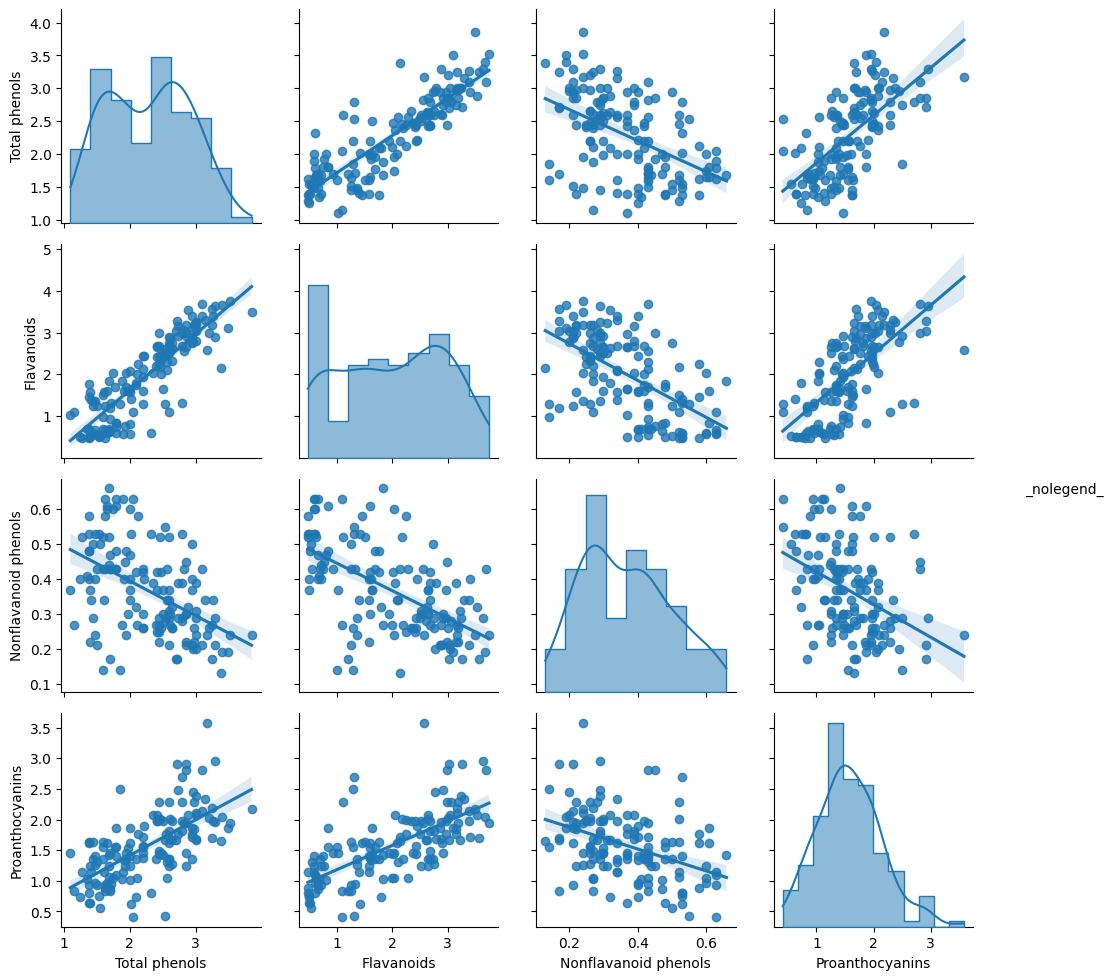

In [14]:
subcols = ['Total phenols', 'Flavanoids', 'Nonflavanoid phenols',
           'Proanthocyanins']
g = sns.PairGrid(Xtrn[subcols])
g.map_diag(sns.histplot, kde=True, element='step')
g.map_offdiag(sns.regplot)
g.add_legend()


## Preparación de los datos

### Valores atípicos


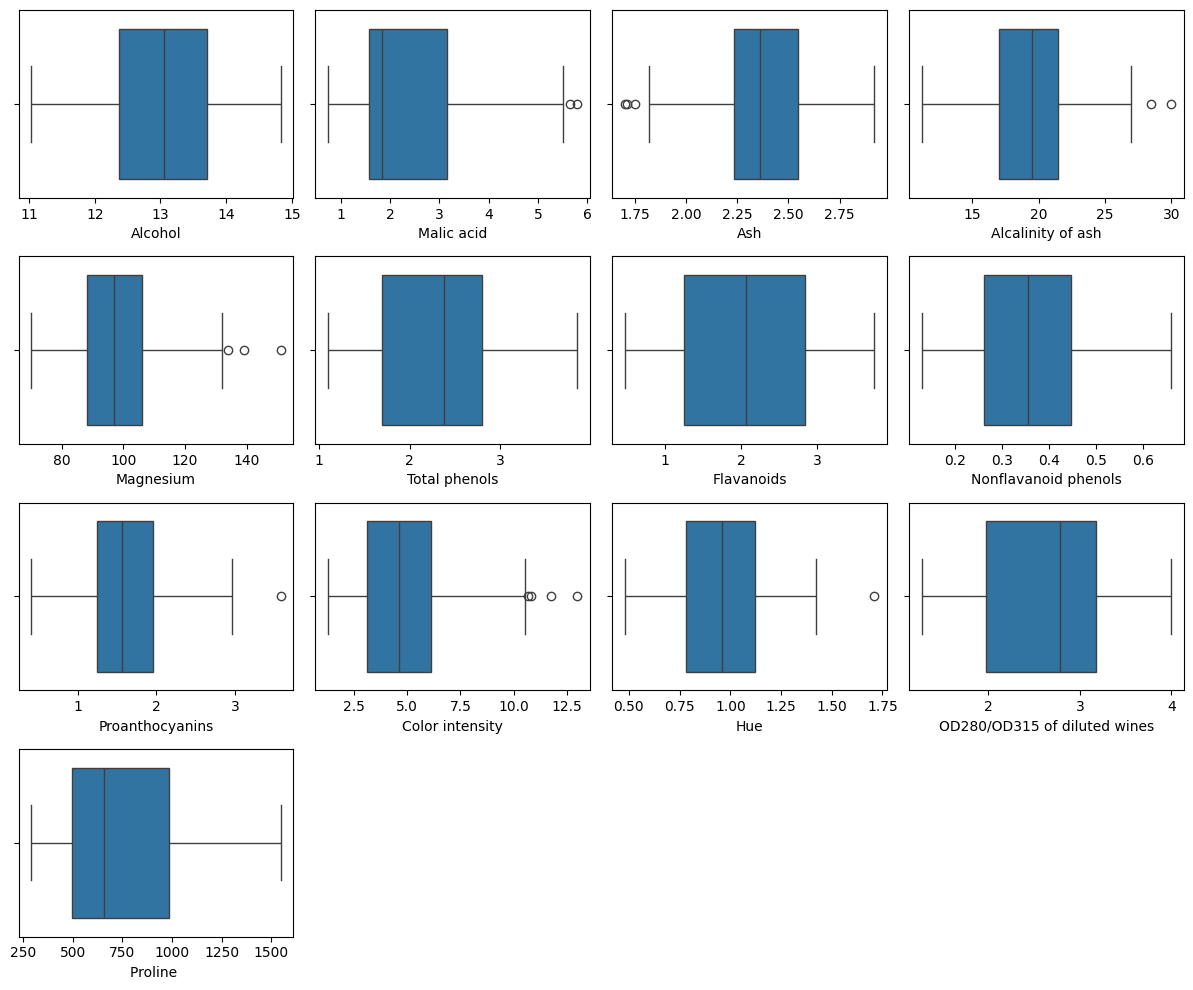

In [15]:
fig, axes = plt.subplots(nrows=4, ncols=4, sharey=False,
                         figsize=(12, 10))
for i, col in enumerate(cols, 1):
    sns.boxplot(data=Xtrn, x=col, ax=axes.flatten()[i-1])

for i in range(len(cols)+1, 17):
    axes.flatten()[i-1].axis('off')

plt.tight_layout()
plt.show()

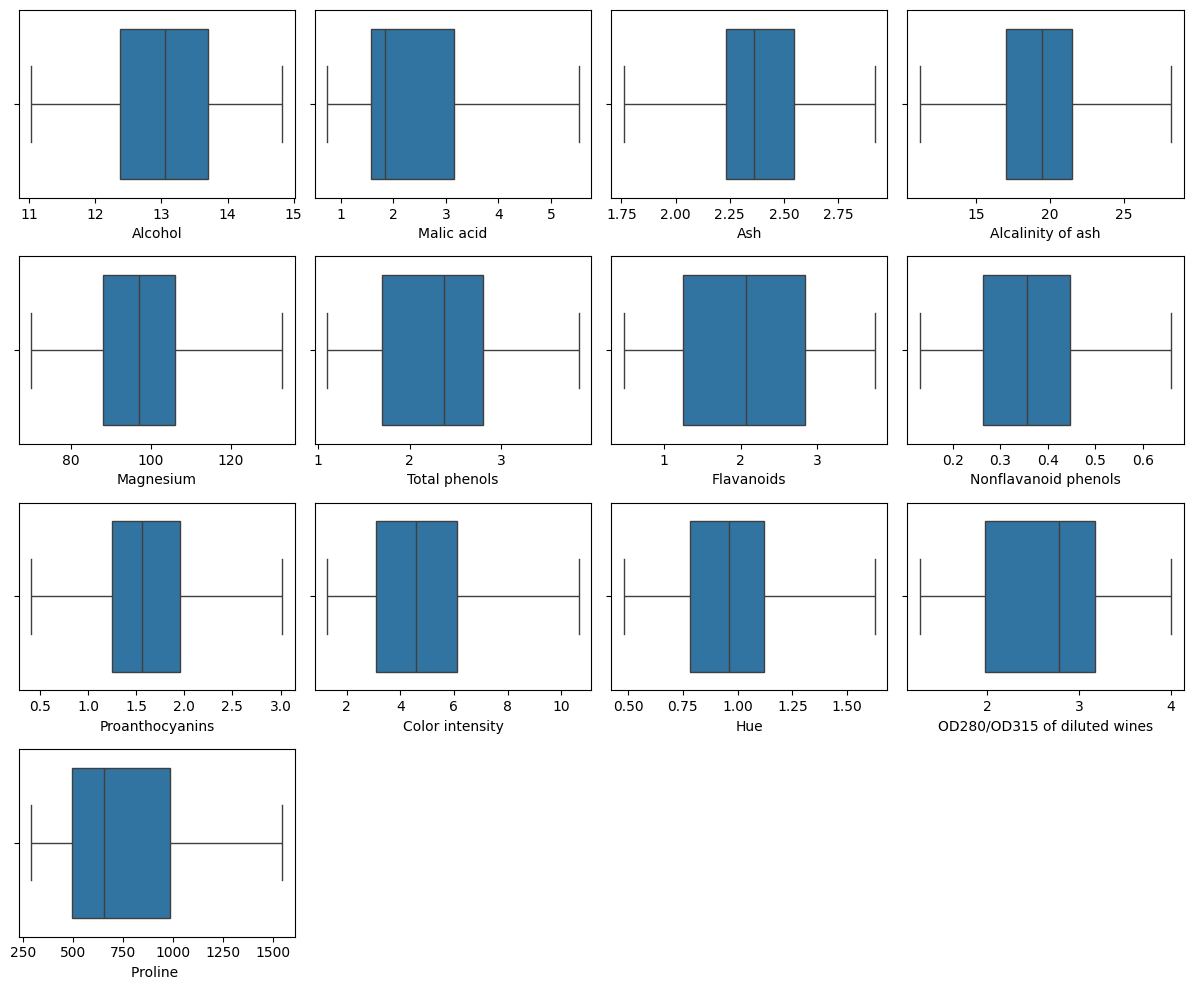

In [18]:
clean = cols[[1, 2, 3, 4, 8, 9, 10]]
X_clean = Xtrn.copy()
winsor = Winsorizer(capping_method='iqr', tail='both',fold=1.5)
X_clean[clean] = winsor.fit_transform(X_clean[clean])

fig, axes = plt.subplots(nrows=4, ncols=4, sharey=False,
                         figsize=(12, 10))
for i, col in enumerate(cols, 1):
    sns.boxplot(data=X_clean, x=col, ax=axes.flatten()[i-1])

for i in range(len(cols)+1, 17):
    axes.flatten()[i-1].axis('off')

plt.tight_layout()
plt.show()

### Escalado

In [19]:
scaler = StandardScaler().set_output(transform="pandas")
X_std = scaler.fit_transform(X_clean)

## Elección del modelo
Los árboles de decisión son modelos robustos frente a valores atípicos y no requieren que los datos estén escalados previamente. Esto los hace muy prácticos para comenzar a experimentar rápidamente con distintos escenarios sin necesidad de un preprocesamiento complejo.

Tarea: comparar el rendimiento utilizando datos limpios y/o escalados.

In [20]:
# Lista de nombres de las variables
features = list(Xtrn.columns)
print(features)

['Alcohol', 'Malic acid', 'Ash', 'Alcalinity of ash', 'Magnesium', 'Total phenols', 'Flavanoids', 'Nonflavanoid phenols', 'Proanthocyanins', 'Color intensity', 'Hue', 'OD280/OD315 of diluted wines', 'Proline ']


In [21]:
# Defino el modelo según los criterios de parada, selección, clasificación y
# partición, eligiendo en principio una profundidad máxima de 3 para
# simplificar la visualización
tree_clf = DecisionTreeClassifier(criterion='gini', max_depth=3,
                min_samples_leaf=1, random_state=13, class_weight= 'balanced')

In [22]:
# Entreno el modelo pasando las variables y las etiquetas de entrenamiento
# correspondientes:
tree_clf.fit(Xtrn, ytrn)

# Predicción en el conjunto de entrenamiento
pred_trn = tree_clf.predict(Xtrn)

# Predicción en el conjunto de prueba
pred_tst = tree_clf.predict(Xtst)

#tableResult(y_train, predictions_train)
tableResult(ytst, pred_tst)

    Actual  Predicted
131      3          3
80       2          2
52       1          1
38       1          1
94       2          2
35       1          1
78       2          2
106      2          2
176      3          3
111      2          2
44       1          1
169      3          3
84       2          2
144      3          3
64       2          2
95       2          2
16       1          1
81       2          1
120      2          2
177      3          3
34       1          1
161      3          3
2        1          1
155      3          3
121      2          3
146      3          3
160      3          3
168      3          3
100      2          2
10       1          1
25       1          1
18       1          1
48       1          1
59       2          2
104      2          2
26       1          1


In [23]:
# Evalúo el rendimiento del modelo
train_accuracy = accuracy_score(ytrn, pred_trn)
test_accuracy = accuracy_score(ytst, pred_tst)
print(f'Train accuracy: {train_accuracy} \nTest accuracy: {test_accuracy}')

Train accuracy: 0.9929577464788732 
Test accuracy: 0.9444444444444444


### Visualización

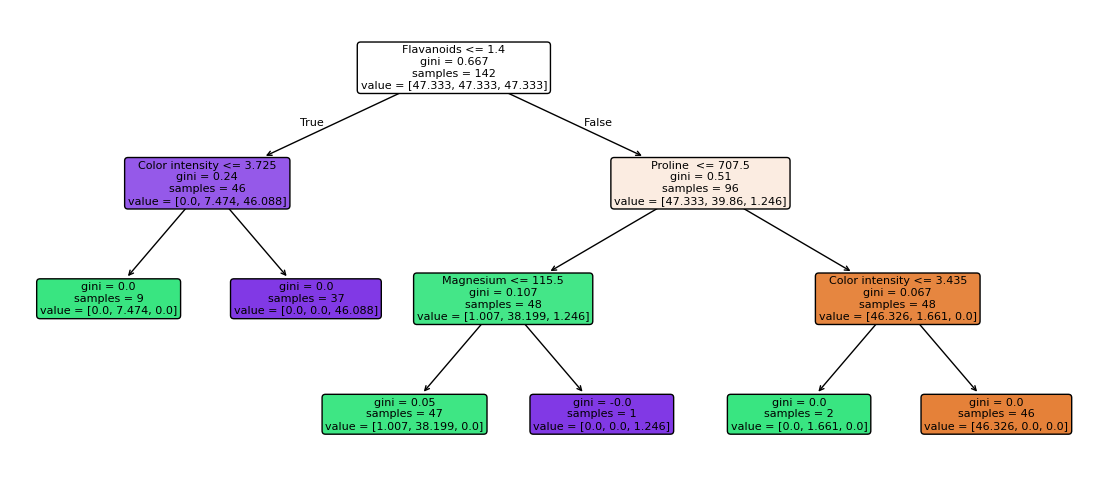

In [24]:
plt.figure(figsize=(14,6))
plot_tree(tree_clf, feature_names=features, fontsize=8, filled=True,
               rounded=True)
plt.show()

In [25]:
r = export_text(tree_clf, feature_names=features)
print(r)

|--- Flavanoids <= 1.40
|   |--- Color intensity <= 3.72
|   |   |--- class: 2
|   |--- Color intensity >  3.72
|   |   |--- class: 3
|--- Flavanoids >  1.40
|   |--- Proline  <= 707.50
|   |   |--- Magnesium <= 115.50
|   |   |   |--- class: 2
|   |   |--- Magnesium >  115.50
|   |   |   |--- class: 3
|   |--- Proline  >  707.50
|   |   |--- Color intensity <= 3.43
|   |   |   |--- class: 2
|   |   |--- Color intensity >  3.43
|   |   |   |--- class: 1



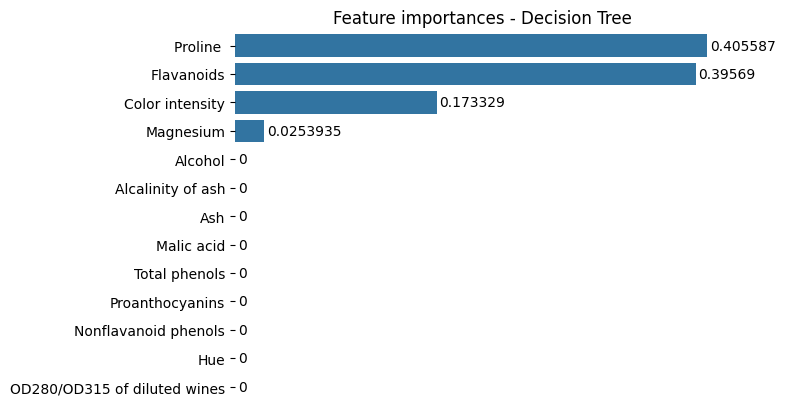

In [26]:
# Creo un df con dos columnas -> Caracteristica y ganacia de información
features_df = pd.DataFrame({'features': features,
                            'importances': tree_clf.feature_importances_ })

# Ordeno en base a la importancia
features_df_sorted = features_df.sort_values(by='importances', ascending=False)

g = sns.barplot(data=features_df_sorted, x='importances', y ='features')
sns.despine(bottom = True, left = True)
g.set_title('Feature importances - Decision Tree')
g.set(xlabel=None, ylabel=None, xticks=[])
for value in g.containers:
    g.bar_label(value, padding=2)

### Optimización de hiperparámetros

In [27]:
param_grid = {
    'max_depth': [3, 4, 5, 6],
    'max_features': [3, 5, 7, 9, 11, 13],
    'random_state': [18]
}
random_search = RandomizedSearchCV(DecisionTreeClassifier(), n_iter=18,
                                   param_distributions=param_grid)
random_search.fit(Xtrn, ytrn)
# Mejores hiperparámetros encontrados durante la búsqueda aleatoria
first_best_params = random_search.best_params_
# Entrenamos el modelo con estos hiperparámetros
best_prediction = random_search.predict(Xtst)
test_accuracy = accuracy_score(ytst, best_prediction)

print(f'{first_best_params} \n {test_accuracy}')


{'random_state': 18, 'max_features': 13, 'max_depth': 4} 
 0.8888888888888888


In [28]:
random_search

RandomizedSearchCV(estimator=DecisionTreeClassifier(), n_iter=18,
                   param_distributions={'max_depth': [3, 4, 5, 6],
                                        'max_features': [3, 5, 7, 9, 11, 13],
                                        'random_state': [18]})

### Métricas

In [29]:
ytst.value_counts()

,count
class,
2,14
1,12
3,10


In [30]:
tableResult(ytst, best_prediction)

    Actual  Predicted
131      3          3
80       2          2
52       1          1
38       1          2
94       2          2
35       1          1
78       2          2
106      2          2
176      3          3
111      2          2
44       1          1
169      3          3
84       2          2
144      3          3
64       2          2
95       2          2
16       1          1
81       2          1
120      2          2
177      3          3
34       1          1
161      3          2
2        1          1
155      3          3
121      2          2
146      3          3
160      3          3
168      3          3
100      2          2
10       1          1
25       1          2
18       1          1
48       1          1
59       2          2
104      2          2
26       1          1


In [31]:
accuracy = accuracy_score(ytst, best_prediction)
precision = precision_score(ytst, best_prediction, average='weighted')
recall = recall_score(ytst, best_prediction, average='weighted')
f1 = f1_score(ytst, best_prediction, average='weighted')
confusion = confusion_matrix(ytst, best_prediction)


In [32]:
print(f'Accuracy: {accuracy},\n\nPrecision: {precision},\n\nRecall: {recall},\n\nF1: {f1}')


Accuracy: 0.8888888888888888,

Precision: 0.896780303030303,

Recall: 0.8888888888888888,

F1: 0.8900500042376471


In [33]:
precision_score(ytst, best_prediction, average=None)

array([0.90909091, 0.8125    , 1.        ])

In [34]:
recall_score(ytst, best_prediction, average=None)

array([0.83333333, 0.92857143, 0.9       ])

In [35]:
f1_score(ytst, best_prediction, average=None)

array([0.86956522, 0.86666667, 0.94736842])

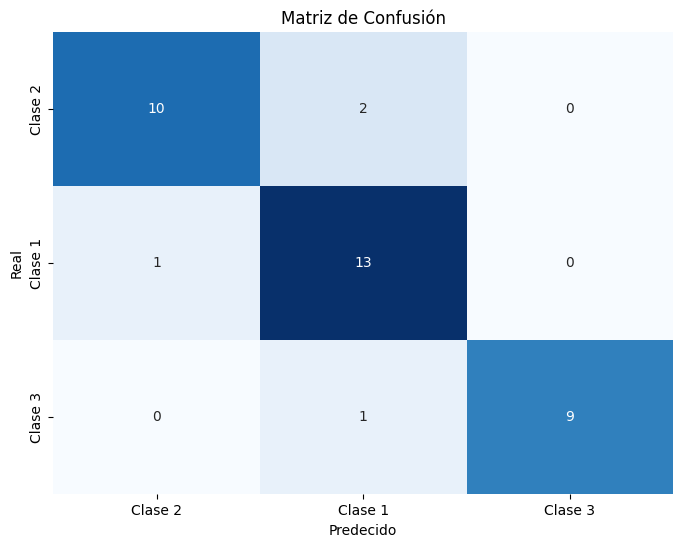

In [36]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Clase 2', 'Clase 1', 'Clase 3'],
            yticklabels=['Clase 2', 'Clase 1', 'Clase 3'],
            cbar=False)
plt.xlabel('Predecido')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

## Preguntas
1. Porque el modelo optimizado tiene menor rendimiento?
2. Los resultados de la matriz de confusión concuerdan con los resultados obtenidos en las métricas? Verificar